In [12]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os
for dirname, _, filenames in os.walk('data'):
    if len(filenames) < 10:
        print(dirname, filenames)

data []
data/Phase1_Train_Dataset []
data/Phase1_Train_Dataset/annotations ['Cells_Anotations_coco.json']


In [13]:
import json

json_path = "data/Phase1_Train_Dataset/annotations/Cells_Anotations_coco.json"

with open(json_path, "r") as f:
    data = json.load(f)

print(type(data))      # dict or list
print(data.keys())     # if it's a dictionary

<class 'dict'>
dict_keys(['info', 'images', 'annotations', 'categories'])


In [14]:
# Build category_id -> category_name mapping
categories = data["categories"]
cat_id_to_name = {cat["id"]: cat["name"] for cat in categories}

print(cat_id_to_name)

{1: 'table', 2: 'table column', 3: 'table row', 4: 'table column header', 5: 'table projected row header', 6: 'table spanning cell'}


In [15]:
from collections import Counter

annotations = data["annotations"]

# Count how many annotations per category_id
category_counts = Counter([ann["category_id"] for ann in annotations])

# Convert to readable names
for cat_id, count in category_counts.items():
    print(f"{cat_id_to_name[cat_id]}: {count}")


table: 1791
table spanning cell: 3567
table projected row header: 1207
table column header: 1453
table row: 20558
table column: 8274


In [16]:
import matplotlib.pyplot as plt
from collections import defaultdict

name_to_cat_id = {v: k for k, v in cat_id_to_name.items()}
def plot_per_image_distribution(category_name):
    cat_id = name_to_cat_id[category_name]
    counts = defaultdict(int)

    for ann in annotations:
        if ann["category_id"] == cat_id:
            counts[ann["image_id"]] += 1

    distribution = Counter(counts.values())

    plt.figure()
    plt.bar(distribution.keys(), distribution.values())
    plt.xlabel(f"Number of {category_name}s in Image")
    plt.ylabel("Number of Images")
    plt.title(f"Distribution of {category_name}s per Image")
    plt.show()



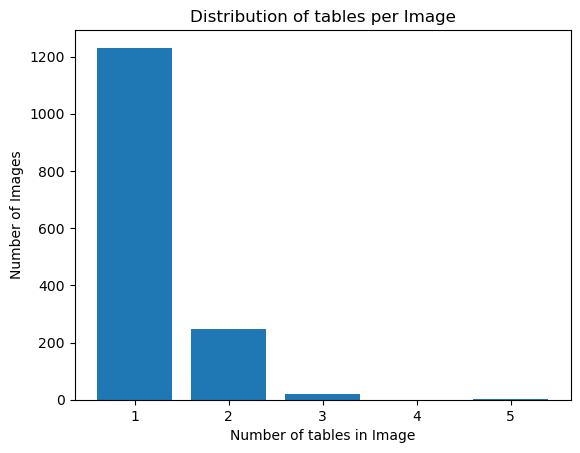

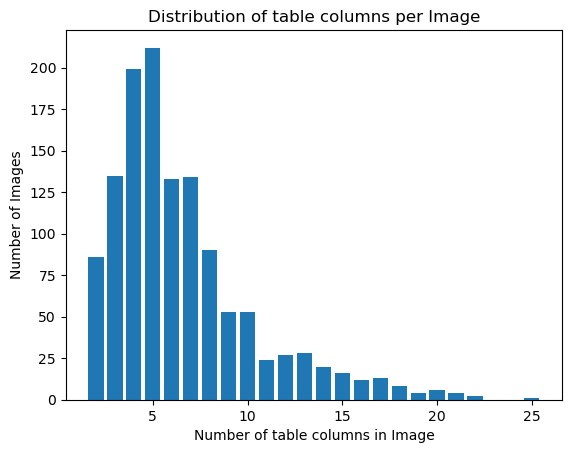

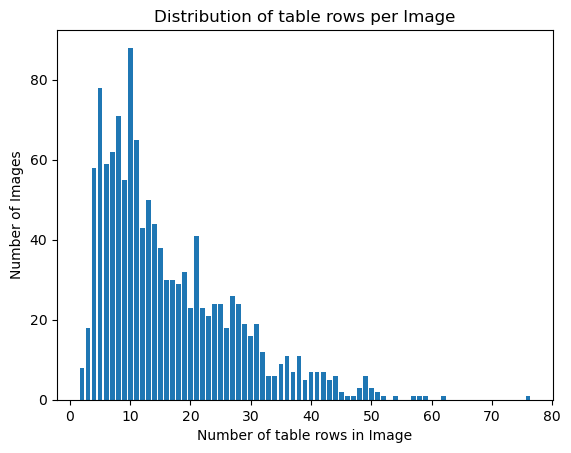

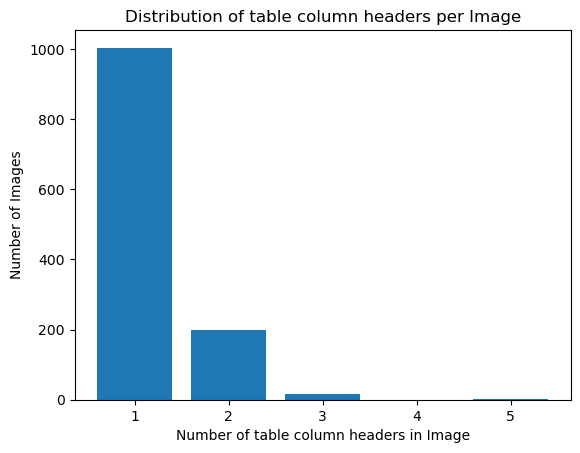

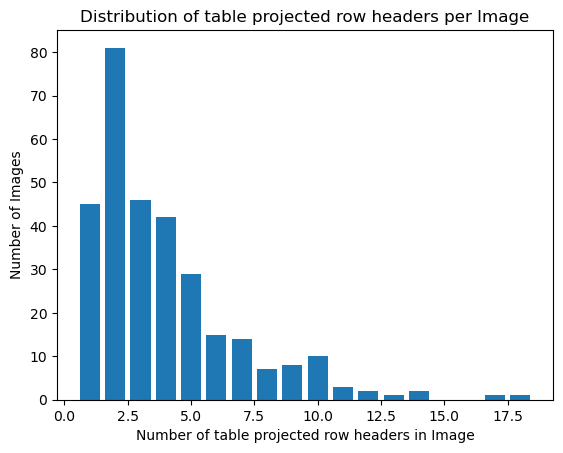

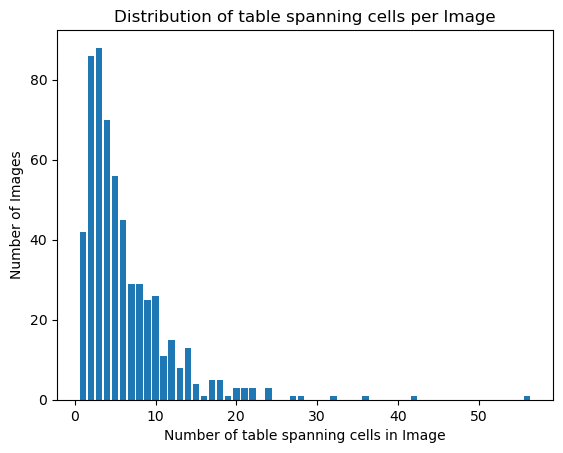

In [17]:

import matplotlib.pyplot as plt

for key in cat_id_to_name:
    plot_per_image_distribution(cat_id_to_name[key])

In [18]:
columns_per_image = defaultdict(int)
images_with_many_columns = {
    img_id: count
    for img_id, count in columns_per_image.items()
    if count > 20
}

# name -> id mapping
name_to_cat_id = {cat["name"]: cat["id"] for cat in data["categories"]}

column_id = name_to_cat_id["table column"]

from collections import defaultdict

columns_per_image = defaultdict(int)

for ann in data["annotations"]:
    if ann["category_id"] == column_id:
        columns_per_image[ann["image_id"]] += 1

# Map image_id -> file_name
image_id_to_name = {img["id"]: img["file_name"] for img in data["images"]}

for img_id, count in images_with_many_columns.items():
    print(image_id_to_name[img_id], count)



In [19]:
import os
import cv2
import matplotlib.pyplot as plt

# path to images folder
images_root = "/kaggle/input/machathon-dataset/Phase1_Train_Dataset/images"

# map image_id -> file_name
image_id_to_name = {img["id"]: img["file_name"] for img in data["images"]}

for img_id in images_with_many_columns:
    file_name = image_id_to_name[img_id]
    img_path = os.path.join(images_root, file_name)

    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.figure()
    plt.figure(figsize=(12, 16))  # Increase size (width, height)
    plt.imshow(image)
    plt.title(f"{file_name} - Columns: {columns_per_image[img_id]}")
    plt.axis("off")
    plt.show()


In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import ipywidgets as widgets
from IPython.display import display
from IPython.display import clear_output

# ----- Select image -----
target_name = "PMC1064076_6.jpg"

image_info = next(
    img for img in data["images"]
    if img["file_name"] == target_name
)

image_id = image_info["id"]

images_root = "data/Phase1_Train_Dataset/images"
img_path = os.path.join(images_root, target_name)

image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# ----- Get annotations -----
image_annotations = [
    ann for ann in data["annotations"]
    if ann["image_id"] == image_id
]

cat_id_to_name = {cat["id"]: cat["name"] for cat in data["categories"]}
unique_categories = sorted(set(cat_id_to_name.values()))

# ----- Styling -----
category_style = {
    "table": {"color": "red", "lw": 3},
    "table column": {"color": "blue", "lw": 2},
    "table row": {"color": "green", "lw": 1.5},
    "table column header": {"color": "purple", "lw": 3},
    "table projected row header": {"color": "orange", "lw": 2.5},
    "table spanning cell": {"color": "cyan", "lw": 1}
}

fig, ax = plt.subplots(figsize=(10, 10))

def update_plot(change=None):
    # This prevents the flickering and removes the old plot
    with output_widget:
        clear_output(wait=True) 
        
        # We must recreate the figure inside the clear_output 
        # for it to reliably refresh in standard notebooks
        fig, ax = plt.subplots(figsize=(10, 10))
        ax.imshow(image)
        ax.axis("off")

        for ann in image_annotations:
            category_name = cat_id_to_name[ann["category_id"]]
            if checkboxes[category_name].value:
                x, y, w, h = ann["bbox"]
                style = category_style.get(category_name, {"color": "white", "lw": 1})
                rect = patches.Rectangle((x, y), w, h, linewidth=style["lw"], 
                                         edgecolor=style["color"], facecolor='none')
                ax.add_patch(rect)
        
        plt.show()

# Create an output container to hold the plot
output_widget = widgets.Output()

# Create checkboxes
checkboxes = {
    cat: widgets.Checkbox(value=True, description=cat)
    for cat in category_style.keys()
}

# Attach update function
for cb in checkboxes.values():
    cb.observe(update_plot, names='value')

# Display UI
display(widgets.VBox(list(checkboxes.values()) + [output_widget]))

# Initial trigger
update_plot()

In [21]:
problem_annotations = []

for ann in data["annotations"]:
    if ann.get("iscrowd", 0) != 0 or ann.get("ignore", 0) != 0:
        problem_annotations.append(ann)

print("Number of annotations with iscrowd != 0 or ignore != 0:")
print(len(problem_annotations))


Number of annotations with iscrowd != 0 or ignore != 0:
0
